# Demo: Contagem de Valores de Moedas em Imagens

## Introdução
Este notebook apresenta um pipeline clássico de processamento digital de imagens desenvolvido para a segmentação, classificação e contagem automática de moedas (5, 10 e 25 centavos) a partir de fotografias. O problema consiste em isolar cada objeto de interesse do fundo da imagem, extrair suas propriedades geométricas (área em pixels) e, com base nessa métrica, inferir o valor monetário individual e total da cena. A metodologia aplicada engloba transformações radiométricas, binarização automática, operações morfológicas para filtragem de ruídos e análise de componentes conexos.

**Visão Geral do Problema**: Dada uma imagem de moedas em uma superfície, identificar cada moeda, classificá-la por denominação com base no tamanho e somar os valores.

**Técnicas Principais**:
- Conversão para escala de cinza para simplificar
- Limiarização para separar moedas do fundo
- Operações morfológicas para limpar a imagem binária
- Componentes conectados para detectar e medir moedas individuais
- Classificação baseada em tamanho (área em pixels correlaciona com tamanho da moeda)

Este método assume que as moedas estão bem separadas e a imagem está limpa. Para cenários mais avançados, aprendizado de máquina poderia ser usado.

**Referências**:
- [Documentação OpenCV](https://docs.opencv.org/4.x/)
- [Fundamentos de Processamento de Imagens](https://en.wikipedia.org/wiki/Digital_image_processing)

## Etapa 1: Configuração e Carregamento de Imagens

**Descrição**: Para o desenvolvimento deste algoritmo, utilizamos as bibliotecas padrão do ecossistema científico do Python: numpy para operações matriciais eficientes, matplotlib para a visualização dos resultados intermediários e a biblioteca cv2 (OpenCV) para a extração avançada de características. Nesta primeira etapa, inicializamos o ambiente e realizamos o download de três imagens de amostra, que representam diferentes arranjos espaciais das moedas, servindo como nossa base de dados (dataset) de entrada.

**Bibliotecas Usadas**:
- `numpy`: Para operações com arrays
- `matplotlib`: Para plotar imagens
- `opencv` (cv2): Para funções de processamento de imagem
- `requests`: Para baixar imagens

**Processo**: Baixar três imagens de exemplo (75.jpg, 80.jpg, 95.jpg) representando diferentes arranjos de moedas. Exibi-las para visualizar a entrada.

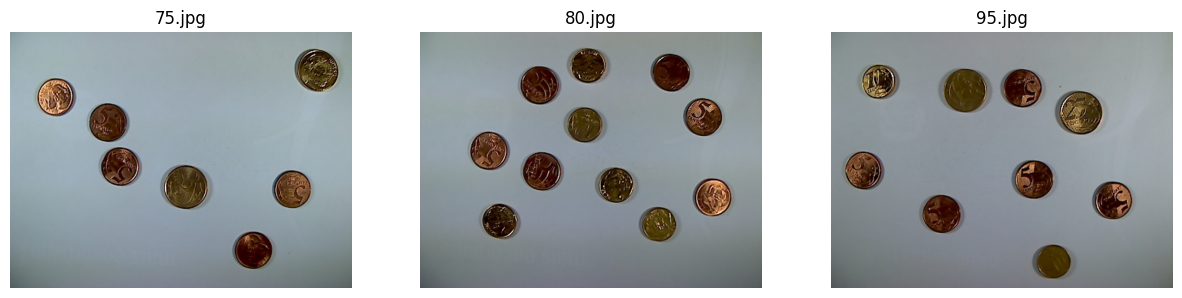

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import requests
import os

def download_image(url: str) -> str:
    filename = os.path.basename(url)
    if os.path.exists(filename):
        return filename
    response = requests.get(url)
    with open(filename, mode="wb") as file:
        file.write(response.content)
    return filename

# Carregar imagens de exemplo (75.jpg, 80.jpg, 95.jpg)
url_base = "https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]
filenames = [download_image(url_base.format(value=v)) for v in values]

# Exibir originais
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
for i, file in enumerate(filenames):
    plt.subplot(1, 3, 1+i)
    plt.axis('off')
    plt.title(file)
    img = mpimg.imread(file)
    plt.imshow(img)
plt.show()

## Etapa 2: Conversão para Escala de Cinza

**Descrição**: Imagens coloridas nativas operam em três canais espaciais (RGB), o que triplica o custo computacional e adiciona informações de cor que, para o problema de identificação de formas e áreas, são redundantes. Para contornar isso, convertemos as matrizes tridimensionais em bidimensionais (escala de cinza). A conversão não foi feita por uma média simples, mas sim pela equação de luminância ponderada:

                 `cinza = 0.3*R + 0.59*G + 0.11*B`. Isso pondera o verde mais pesadamente, pois corresponde à percepção humana.

Essa ponderação favorece o canal verde, aproximando a matriz resultante da resposta de sensibilidade do olho humano e garantindo um contraste mais fiel entre o metal das moedas e o fundo da imagem.

**Por quê?**: Reduz de 3 canais (RGB) para 1, tornando a limiarização e morfologia mais rápidas e confiáveis.

**Exemplo**: Processar uma imagem e exibir o resultado.

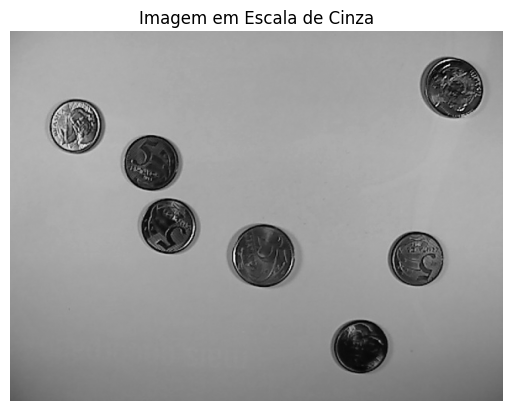

Forma original: (480, 640, 3), Forma em cinza: (480, 640)


In [5]:
# Exemplo para uma imagem
img = mpimg.imread(filenames[0]).astype('uint8')
img_gray = np.uint8(0.3*img[:,:,0] + 0.59*img[:,:,1] + 0.11*img[:,:,2])
plt.imshow(img_gray, cmap='gray')
plt.title("Imagem em Escala de Cinza")
plt.axis('off')
plt.show()
print(f"Forma original: {img.shape}, Forma em cinza: {img_gray.shape}")

## Etapa 3: Segmentação e Processamento Morfológico

**Descrição**: O passo crítico da segmentação é isolar as moedas do fundo escuro. Para isso, aplicamos a função de limiarização utilizando o Método de Otsu, que calcula de forma analítica e automática o limiar ideal baseando-se na variância do histograma da imagem, gerando uma matriz binária.

No entanto, a binarização crua costuma apresentar artefatos. Para suavizar as bordas e preencher falhas internas (como o relevo da efígie ou os números cravados na moeda), aplicamos técnicas de morfologia matemática. Primeiramente, realizamos a operação de Fechamento (com um kernel de 15x15) para unificar a massa de pixels de cada moeda. Em seguida, aplicamos a operação de Abertura (com um kernel maior, de 31x31) para eliminar pequenos ruídos isolados no fundo da imagem, garantindo que apenas as moedas reais permaneçam na matriz resultante.

**Limiarização**: Usar o método de Otsu (`cv2.THRESH_BINARY + cv2.THRESH_OTSU`) para seleção automática de limiar. Inverter a imagem primeiro (255 - img) pois as moedas são mais escuras.

**Operações Morfológicas**:
- **Fechamento** (`cv2.MORPH_CLOSE`): Preenche pequenas lacunas dentro das moedas usando um kernel 15x15.
- **Abertura** (`cv2.MORPH_OPEN`): Remove pequenos ruídos usando um kernel 31x31.

**Parâmetros Escolhidos**: Tamanhos de kernel baseados nos tamanhos das moedas em pixels; maiores para abertura para evitar remover moedas.

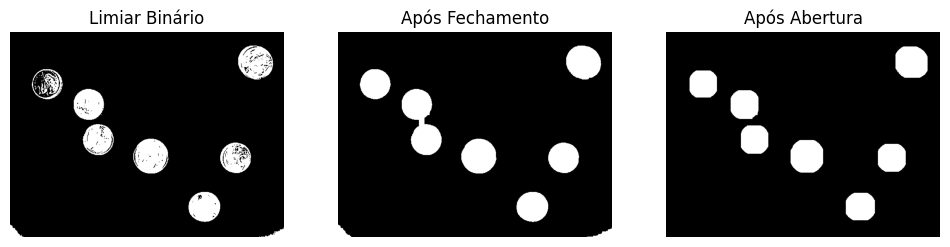

In [6]:
def seg_and_postprocessing(img, k_cl, k_op):
    # Limiarização com método de Otsu
    binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    
    # Morfológico fechamento
    kernel_cl = np.ones((k_cl, k_cl), np.uint8)
    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1)
    
    # Morfológico abertura
    kernel_op = np.ones((k_op, k_op), np.uint8)
    open_img = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)
    
    # Exibir etapas intermediárias
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(binr, cmap='gray')
    plt.title("Limiar Binário")
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(close, cmap='gray')
    plt.title("Após Fechamento")
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(open_img, cmap='gray')
    plt.title("Após Abertura")
    plt.axis('off')
    plt.show()
    
    return open_img

seg_img = seg_and_postprocessing(img_gray, 15, 31)

## Etapa 4: Análise de Componentes Conectados

**Descrição**:  Com as regiões de interesse devidamente segmentadas e limpas, o algoritmo precisa compreender que aqueles grupos de pixels brancos formam objetos distintos. Para isso, aplicamos a análise de componentes conexos com conectividade 4. Esse método varre a imagem binária e atribui um "rótulo" numérico (label) exclusivo para cada ilha contígua de pixels. Além de isolar visualmente cada moeda, essa função extrai propriedades fundamentais de cada região, como as coordenadas do seu centro de massa (centróide) e, principalmente, a sua área total.

**Método**: `cv2.connectedComponentsWithStats` com conectividade=4 (vizinhos 4-conectados). Retorna rótulos, estatísticas (área, centróide, etc.) e centróides.

**Saída**: Uma imagem rotulada onde cada moeda tem um rótulo inteiro único. Estatísticas fornecem medições para classificação.

**Por que 4-conectado?**: Adequado para formas em nível de pixel; evita conexões diagonais que podem mesclar moedas próximas.

**Referência**: [Componentes Conectados](https://docs.opencv.org/master/d3/dc0/group__imgproc__shape.html)

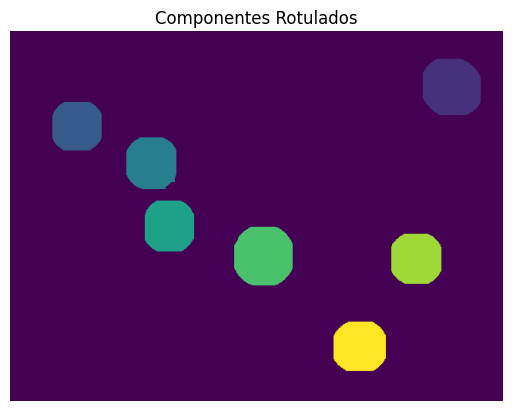

Número de componentes: 8


In [ ]:
output = cv2.connectedComponentsWithStats(seg_img, 4)
# output[0]: número de rótulos
# output[1]: imagem rotulada
# output[2]: estatísticas (área, etc.)
# output[3]: centróides

plt.imshow(output[1])
plt.title("Componentes Rotulados")
plt.axis('off')
plt.show()
print(f"Número de componentes: {output[0]}")

## Etapa 5: Classificação e Cálculo de Valor

**Descrição**: A etapa final consiste em traduzir os dados geométricos extraídos em valores financeiros. Ao analisarmos a correlação entre as propriedades físicas das moedas brasileiras e sua representação na imagem, notou-se que a área do componente rotulado funciona como um excelente classificador.

Empiricamente, definimos os seguintes limites de decisão:

- Componentes com área inferior a 3.500 pixels são classificados como moedas de 10 centavos (que possuem o menor diâmetro físico).

- Componentes com área superior a 4.600 pixels são classificados como moedas de 25 centavos (as maiores do conjunto).

Valores intermediários são classificados como moedas de 5 centavos.

Por fim, utilizamos as coordenadas dos centróides extraídas na etapa anterior para plotar o valor correspondente sobre cada moeda, contabilizando e exibindo a soma financeira final da cena.

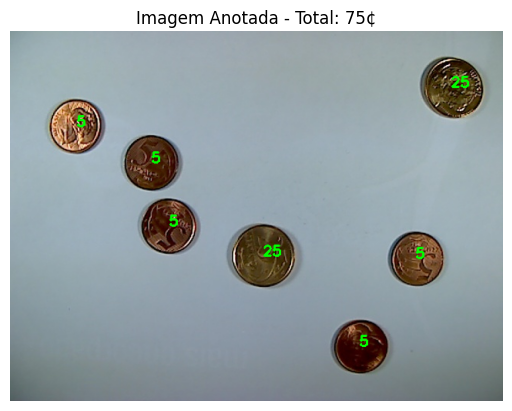

Moedas: 7, Áreas: [np.int64(4805), np.int64(3638), np.int64(3867), np.int64(3786), np.int64(5016), np.int64(3767), np.int64(3861)], Total: 75¢


In [ ]:
def calc_npixels_label(img, n_labels):
    list_npixels = []
    for v in range(n_labels-1):
        npixels = (img[img == v+1] // (v+1)).sum()
        list_npixels.append(npixels)
    return list_npixels

list_npixels = calc_npixels_label(output[1], output[0])
soma = 0
for n, p in enumerate(list_npixels):
    x, y = int(output[3][n+1][0]), int(output[3][n+1][1])
    if p < 3500:
        soma += 10
        cv2.putText(img, '10', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    elif p > 4600:
        soma += 25
        cv2.putText(img, '25', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    else:
        soma += 5
        cv2.putText(img, '5', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.imshow(img)
plt.title(f"Imagem Anotada - Total: {soma}¢")
plt.axis('off')
plt.show()
print(f"Moedas: {len(list_npixels)}, Áreas: {list_npixels}, Total: {soma}¢")

## Conclusão

Este pipeline segmenta com sucesso as moedas das imagens, classifica-as por tamanho e calcula o valor total. Funciona bem para as amostras fornecidas, mas pode falhar com moedas sobrepostas, iluminação variável ou tamanhos diferentes de moedas.

**Limitações**:
- Assume tamanhos fixos de moedas e fundos limpos.
- A limiarização pode precisar de ajuste para imagens diferentes.

**Melhorias**: Usar aprendizado de máquina para melhor classificação ou adicionar análise de contorno para verificação de forma.

## Referências
- [Tutorial de Limiarização OpenCV](https://docs.opencv.org/master/d7/d4d/tutorial_py_thresholding.html)
- [Operações Morfológicas](https://docs.opencv.org/master/d9/df8/tutorial_py_morphological_ops.html)
- [Componentes Conectados com Estatísticas](https://docs.opencv.org/master/d3/dc0/group__imgproc__shape.html)
- [Documentação NumPy](https://numpy.org/doc/stable/)
- [Tutorial de Imagens Matplotlib](https://matplotlib.org/3.5.0/tutorials/introductory/images.html)